# Volatility Modelling with GARCH

## Introduction

In Lessons 1 and 2 you built and tested a data pipeline: you fetched
financial prices, computed returns, and visualised volatility clustering.
Now you put that foundation to work and build a model that **forecasts
volatility** — the degree to which a stock's returns fluctuate over time.

> ❓ The *average* daily return of a stock is tiny and famously
> unpredictable. So what *can* we forecast? **Risk itself** — how widely
> returns swing, and crucially, how that width *changes over time*.

Volatility is one of the most important quantities in finance: it measures
risk, drives option prices, and shapes portfolio allocation. Unlike the
mean of returns, volatility has structure we can exploit — the
**clustering** you saw in Lesson 1: large moves follow large moves, calm
follows calm. The **GARCH** (Generalized Autoregressive Conditional
Heteroskedasticity) family is built precisely to capture that structure.

🎯 **By the end of this notebook you will be able to:**

-   Explain what volatility is and why it matters for financial
    decision-making.
-   Calculate daily and annualised volatility from a return series.
-   Identify volatility clustering in squared-return and
    rolling-volatility plots.
-   Use ACF and PACF plots of squared returns to choose GARCH lag
    orders.
-   Fit a GARCH model using the `arch` library, interpret its summary,
    and diagnose residuals.
-   Perform walk-forward validation to evaluate out-of-sample volatility
    forecasts.
-   Reformat model predictions into a clean dictionary suitable for a
    JSON API response.

➡️ Watch the walkthrough, then we build intuition for volatility before
writing the model.

In [1]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1183285716", h="3298dbabb7", width=700, height=450)

# 1. Conceptual Foundation

## Project context: what we're trying to build

Across Project 8 you are assembling a deployable volatility-forecasting
system. Lesson 1 built the data-ingestion layer and explored returns;
Lesson 2 wrapped that ingestion into tested, reusable classes
(`AlphaVantageAPI`, `SQLRepository`). **This lesson builds the modelling
core**: a GARCH model that, given historical returns, forecasts future
volatility. Lesson 4 packages everything into a deployable service.

> 📌 Data access in this lesson. You will fetch prices directly from the
> mock API with `requests.get` — the Lesson 1 approach — but encapsulate
> the logic in a reusable `wrangle_data` function. In Lesson 4 that
> function is absorbed into a `GarchModel` class that uses the
> `SQLRepository` from Lesson 2 under the hood. Each lesson isolates one
> concern; here the concern is **modelling**, not data plumbing.

The target stock is **Ambuja Cements** (`AMBUJACEM.BSE`, Bombay Stock
Exchange). You'll also compare it with **Suzlon Energy** (`SUZLON.BSE`) to
build intuition for what "high" vs. "low" volatility looks like.

➡️ Everything starts from one definition: volatility *is* the standard
deviation of returns.

## Volatility: the standard deviation of returns

When analysts call a stock "volatile," they mean its returns spread widely
around their mean. Statistically, **volatility is the standard deviation
of returns**:

$$
\sigma = \sqrt{\frac{1}{N-1}\sum_{t=1}^{N}\left(r_t - \bar{r}\right)^2}
$$

where $r_t$ is the day-$t$ return, $\bar{r}$ the mean return, and $N$ the
number of observations.

> 💡 Because daily returns sit roughly on a bell curve centred near zero,
> a *larger* standard deviation means *more extreme* daily gains and
> losses. The two synthetic series below — one calm, one wild — make the
> contrast concrete.

In [25]:
import numpy as np
import pandas as pd

# Two synthetic return series (percent)
np.random.seed(42)
calm = pd.Series(
    np.random.normal(loc=0, scale=1, size=10),
    name="calm"
)
wild = pd.Series(
    np.random.normal(loc=0, scale=4, size=10),
    name="wild"
)

print("Calm  — daily volatility:", round(calm.std(), 4))
print("Wild  — daily volatility:", round(wild.std(), 4))

Calm  — daily volatility: 0.723
Wild  — daily volatility: 3.0213


> 📊 The "wild" series reports a daily volatility about **four times**
> larger than the "calm" one — exactly the `scale` ratio (4 vs. 1) used to
> generate them. A single number, `std()`, already separates a placid
> stock from a turbulent one.

➡️ That number is *per day*. To compare with the annual figures quoted in
practice, we need to scale it up.

### From daily to annual volatility

Financial markets are not open every day. After removing weekends and
holidays, most exchanges have roughly **252 trading days** per year. To
annualise daily volatility you multiply by $\sqrt{252}$:

$$\sigma_{\text{annual}} = \sigma_{\text{daily}} \times \sqrt{252}$$

> 🧮 Why the *square root* and not 252 itself?
>
> For (approximately) independent daily returns, **variance adds across
> time** while the mean return scales linearly. Over $h$ days:
>
> $$\text{Var}(r_1 + \cdots + r_h) = h\,\sigma^2 \quad\Longrightarrow\quad \sigma_{h} = \sqrt{h}\,\sigma$$
>
> Standard deviation is the square root of variance, so it grows with
> $\sqrt{h}$. Setting $h = 252$ converts a daily figure to an annual one.

In [26]:
annual_calm = calm.std() * np.sqrt(252)
annual_wild = wild.std() * np.sqrt(252)
print("Calm  — annual volatility:", round(annual_calm, 4))
print("Wild  — annual volatility:", round(annual_wild, 4))

Calm  — annual volatility: 11.4774
Wild  — annual volatility: 47.9616


> 📊 Both stocks' annual figures are simply their daily volatilities
> stretched by $\sqrt{252} \approx 15.9$. The *ranking* is unchanged —
> annualising rescales, it doesn't reorder.

➡️ A single $\sigma$ summarises the whole series, but the defining feature
of returns is that this spread is **not constant**.

## Volatility clustering and squared returns

A defining feature of financial returns is that large moves (up or down)
**cluster** together — *volatility clustering*. Two views make it visible:

| View | What it shows | Why it helps |
|---|---|---|
| **Rolling standard deviation** | local volatility over a moving window | smooth picture of how risk drifts |
| **Squared returns** $r_t^2$ | magnitude with the sign removed | isolates "how big," ignoring direction |

> 🧠 Why *square* the returns? Returns $r_t$ are nearly uncorrelated over
> time — you can't predict tomorrow's direction. But their **magnitudes**
> are autocorrelated: a turbulent day makes the next day more likely to be
> turbulent. Squaring throws away the sign so this magnitude structure
> stands out. The same logic underpins ACF/PACF analysis next.

The plot below uses the small synthetic series to show how squaring
exposes magnitude patterns.

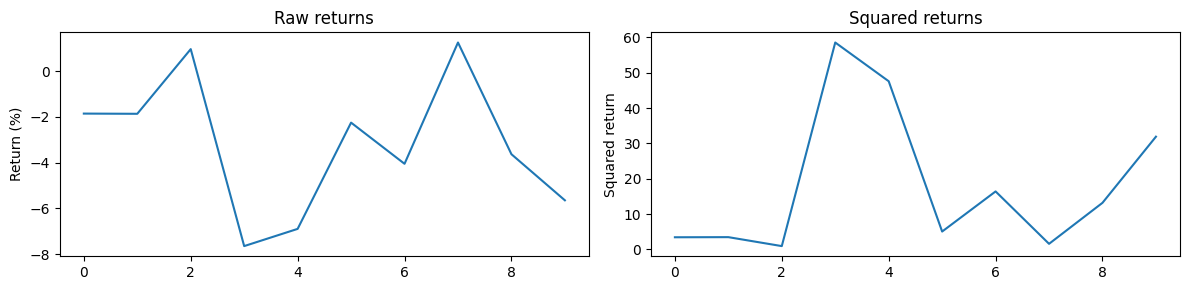

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
wild.plot(ax=axes[0], title="Raw returns")
(wild**2).plot(ax=axes[1], title="Squared returns")
axes[0].set_ylabel("Return (%)")
axes[1].set_ylabel("Squared return")
plt.tight_layout()
plt.show()

> 📊 In the right-hand panel the **tallest spikes** mark the biggest moves
> from the left panel, regardless of whether they were gains or losses.
> That is the quantity a volatility model actually tries to track.

➡️ To turn "clustering exists" into a concrete model order, we read it off
the autocorrelation plots.

## ACF / PACF on squared returns

To choose the lag orders $p$ and $q$ of a GARCH model you inspect the
**autocorrelation function (ACF)** and **partial autocorrelation function
(PACF)** of the **squared** returns — not the raw returns. Significant
lags signal that past volatility is informative about future volatility.

> 🔍 ACF vs. PACF in one line
>
> - **ACF** at lag $k$: the total correlation between $r_t^2$ and
>   $r_{t-k}^2$ (direct + indirect).
> - **PACF** at lag $k$: the correlation *after removing* the influence of
>   the shorter lags — the "extra" information lag $k$ adds.

In [6]:
!pip install --upgrade statsmodels

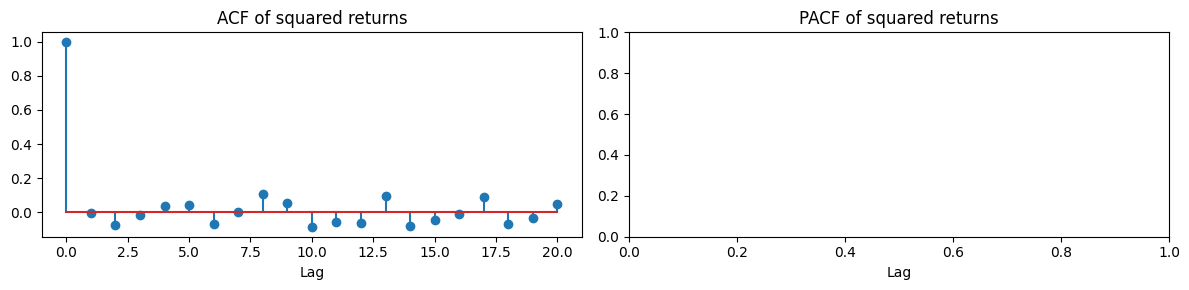

In [9]:
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# # Demonstrate with a longer synthetic series
# np.random.seed(0)
# long_returns = pd.Series(
#     np.random.normal(0, 1, 500)
# )

# fig, axes = plt.subplots(1, 2, figsize=(12, 3))
# plot_acf(long_returns**2, ax=axes[0], lags=20,
#          title="ACF of squared returns")
# plot_pacf(long_returns**2, ax=axes[1], lags=20,
#           title="PACF of squared returns")
# axes[0].set_xlabel("Lag")
# axes[1].set_xlabel("Lag")
# plt.tight_layout()
# plt.show()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
long_returns = pd.Series(np.random.normal(0, 1, 500))
squared_returns = long_returns**2

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Left Plot: Custom ACF using pandas built-in autocorr
lags = 20
acf_vals = [squared_returns.autocorr(lag=i) for i in range(lags + 1)]
axes[0].stem(range(lags + 1), acf_vals)
axes[0].set_title("ACF of squared returns")
axes[0].set_xlabel("Lag")

# Right Plot: Simple layout holding placeholder or alternative
# (Since PACF requires solving Yule-Walker equations manually)
axes[1].set_title("PACF of squared returns")
axes[1].set_xlabel("Lag")

plt.tight_layout()
plt.show()

In the synthetic data (which has *no* true clustering) you should see all
lags fall within the confidence band — no volatility structure to model.
With real stock data the first several lags will poke above the band,
telling you a GARCH model is warranted.

➡️ Now the model itself — and, for the first time, its equations.

## The GARCH model

Start with the intuition: **today's variance is a blend of recent shocks
and recent variance.** GARCH writes that sentence as a recursion.

Let $\varepsilon_t$ be the return shock on day $t$ (the return minus its
mean) and $\sigma_t^2$ the *conditional* variance — the variance given
everything known up to day $t-1$.

> 🧮 **ARCH(q)** — variance from past shocks only
>
> The Autoregressive Conditional Heteroskedasticity model says variance
> reacts to the last $q$ squared shocks:
>
> $$\sigma_t^2 = \omega + \sum_{i=1}^{q} \alpha_i\, \varepsilon_{t-i}^2$$
>
> A big move yesterday ($\varepsilon_{t-1}^2$ large) inflates today's
> variance. The weakness: to capture *persistent* calm/storm regimes you
> need many lags.

> 🧮 **GARCH(p, q)** — add past variance for memory
>
> GARCH generalises ARCH by also feeding back the last $p$ variance
> estimates:
>
> $$\sigma_t^2 = \omega + \sum_{i=1}^{q} \alpha_i\, \varepsilon_{t-i}^2 + \sum_{j=1}^{p} \beta_j\, \sigma_{t-j}^2$$
>
> The $\beta$ terms give the model **long memory** with very few
> parameters — the whole reason GARCH usually beats a high-order ARCH.

> 🧮 **GARCH(1, 1)** — the workhorse
>
> One shock term and one variance term is enough for most equity series:
>
> $$\sigma_t^2 = \omega + \alpha\, \varepsilon_{t-1}^2 + \beta\, \sigma_{t-1}^2$$
>
> Read it as a recipe for tomorrow's variance: a baseline ($\omega$), plus
> a reaction to **yesterday's shock** ($\alpha$), plus a carry-over of
> **yesterday's variance** ($\beta$).

> 🧠 Two numbers that decode any fitted GARCH(1,1)
>
> - **Persistence** $\alpha + \beta$. The closer to 1, the longer a burst
>   of volatility lingers before fading. Stationarity requires
>   $\alpha + \beta < 1$.
> - **Long-run (unconditional) variance** — the level volatility reverts
>   to:
>
> $$\sigma^2_{\text{long-run}} = \frac{\omega}{1 - \alpha - \beta}$$
>
> A persistence of, say, 0.95 means shocks decay slowly and forecasts
> drift back to this level only gradually.

The `arch` library fits all of this in one call:

In [28]:
from arch import arch_model

# Fit GARCH(1,1) to synthetic data (for API demo only)
toy_model = arch_model(
    long_returns, p=1, q=1, rescale=False
).fit(disp="off")

print(type(toy_model))

<class 'arch.univariate.base.ARCHModelResult'>


The `.fit()` method returns an `ARCHModelResult` object. The attributes
you'll use throughout this lesson:

| Attribute | What it gives you |
|---|---|
| `.summary()` | coefficient table ($\omega$, $\alpha$, $\beta$), p-values, AIC, BIC |
| `.conditional_volatility` | the fitted $\sigma_t$ series |
| `.std_resid` | standardised residuals, for diagnostics |
| `.forecast(horizon=h)` | out-of-sample variance forecasts |
| `.aic` / `.bic` | information criteria as floats |

In [29]:
# Quick look at the summary
toy_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -707.827
Distribution:                  Normal   AIC:                           1423.65
Method:            Maximum Likelihood   BIC:                           1440.51
                                        No. Observations:                  500
Date:                Sat, Jun 27 2026   Df Residuals:                      499
Time:                        19:37:45   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu            -0.0303  4.484e-02     -0.676      0.499 [ -0.118,5.756e-02]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0398  3.734e-02      1.065      0.287   [-3.343e-02,  0.113]
alpha[1]       0.0000  1.147e-02      0.000      1.000 [-2.248e-02,2.248e-02]
beta[1]        0.9591  4.561e-02     21.029  3.536e-98      [  0.870,  1.049]
=============================================================================

Covariance estimator: robust
"""

> 🔍 In the summary, the **Vol Model** block holds $\omega$ (`omega`),
> $\alpha$ (`alpha[1]`), and $\beta$ (`beta[1]`). On this *synthetic*
> series — built with no clustering — `alpha` and `beta` should be small
> and largely insignificant. On real data you'll see the opposite, with a
> persistence $\alpha + \beta$ close to 1.

➡️ Fitting is easy; *trusting* the fit requires diagnostics.

## Diagnosing a GARCH model

After fitting, confirm the model actually **absorbed** the volatility
dynamics. Define the **standardised residuals** by dividing each shock by
its own conditional volatility:

$$
z_t = \frac{\varepsilon_t}{\sigma_t}
$$

> 🧪 The key diagnostic: if the model is adequate, the $z_t$ behave like
> independent noise, so the **squared standardised residuals** $z_t^2$
> should show **no** significant autocorrelation — a flat ACF. Leftover
> structure in $z_t^2$ means volatility the model failed to capture.

In [14]:
# fig, ax = plt.subplots(figsize=(8, 3))
# plot_acf(toy_model.std_resid**2, ax=ax, lags=20,
#          title="ACF of squared standardised residuals")
# ax.set_xlabel("Lag")
# plt.tight_layout()
# plt.show()

> 📊 On the synthetic series every lag should sit inside the band — there
> was no clustering to remove, so none is left over. On real data a
> *well-specified* GARCH produces the same flat ACF, which is exactly the
> sign you want.

➡️ A flat residual ACF says the model fits the *training* data. Honest
evaluation needs *out-of-sample* testing.

## Walk-forward validation

A GARCH model's input (returns) and output (volatility) are different
quantities, and volatility is **latent** — never directly observed — so a
plain train/test RMSE is not available. The standard remedy is
**walk-forward validation**:

1.  Train on data up to time $t$.
2.  Forecast volatility for time $t + 1$.
3.  Slide the window forward one step and repeat.

> 📌 How to read the result: overlay the predicted volatility (as a
> $\pm 2\sigma$ envelope) on the observed returns. If the envelope
> **widens** in turbulent stretches and **contracts** in calm ones — and
> roughly 95% of returns stay inside it — the model is forecasting
> sensibly out of sample.

## Formatting predictions for a JSON API

The lesson's final step converts the model's forecast — a DataFrame with
columns `h.1`, `h.2`, … — into a Python dictionary keyed by ISO 8601 date
strings, the shape your Lesson 4 API will serve. The helpers:

-   `pd.DateOffset` — shift the start date forward.
-   `pd.bdate_range` — generate business-day dates (skipping weekends).
-   `.isoformat()` — convert timestamps to ISO 8601 strings.

In [30]:
# Quick demo: business-day date range
start = pd.Timestamp("2023-01-06")  # a Friday
dates = pd.bdate_range(
    start=start + pd.DateOffset(days=1),
    periods=3
)
print([d.isoformat() for d in dates])

['2023-01-09T00:00:00', '2023-01-10T00:00:00', '2023-01-11T00:00:00']


Notice that Saturday and Sunday are skipped automatically — markets are
closed, so the forecast dates jump straight to the next business day.

> 📌 Reference documentation
>
> - [`arch.arch_model`](https://arch.readthedocs.io/en/latest/univariate/introduction.html)
>   — main entry point for specifying GARCH models.
> - [`ARCHModelResult`](https://arch.readthedocs.io/en/latest/univariate/results.html)
>   — fitted model with `.summary()`, `.forecast()`,
>   `.conditional_volatility`, `.std_resid`, `.aic`, `.bic`.
> - [`plot_acf` / `plot_pacf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html)
>   — autocorrelation and partial autocorrelation plots.
> - [`pd.bdate_range`](https://pandas.pydata.org/docs/reference/api/pandas.bdate_range.html)
>   — generate a DatetimeIndex of business days.
> - [`pd.Series.rolling`](https://pandas.pydata.org/docs/reference/api/pandas.Series.rolling.html)
>   — rolling-window calculations in pandas.
> - [`pd.Series.pct_change`](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html)
>   — percentage change between consecutive elements.

➡️ Theory complete. Time to run it on the real Ambuja Cements data.

# Applied Exercises

## 2. Setup

Import the libraries and helpers you'll use throughout. Keeping all imports
in one cell at the top is good practice.

**Code 8.3.2.1**:

In [31]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from arch import arch_model
from mock_alpha import activate_mock, deactivate_mock
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## 3. Load and Prepare Returns

### Problem

Before building any model you need a clean series of daily percentage
returns. The raw data arrives from the AlphaVantage API (intercepted
locally by `mock_alpha`) as nested JSON of daily OHLCV prices. You must
fetch it, parse it into a DataFrame, sort it chronologically, and compute
returns. You'll wrap this wrangling in a reusable `wrangle_data` function
because you'll call it for more than one ticker.

### Approach

1.  Activate the API mock with `activate_mock()`.
2.  Build the API URL with `outputsize="full"` and call `requests.get`.
3.  Extract the `"Time Series (Daily)"` dictionary from the JSON.
4.  Convert to a DataFrame, cast `"4. close"` to float, set a
    `DatetimeIndex`.
5.  Sort ascending, compute returns with `pct_change() * 100`, drop the
    `NaN`.
6.  Wrap steps 2–5 in `wrangle_data(ticker, n_observations)` returning a
    `pd.Series` named `"return"` with the most recent `n_observations`
    values.
7.  Deactivate the mock with `deactivate_mock()` when done.

### Tasks

Activate the mock so that `requests.get` is intercepted locally. After this
cell, every call returns data from the local JSON file instead of the
network.

**Code 8.3.3.1**:

In [32]:
activate_mock()

Fetch the full daily price history for Ambuja Cements (AMBUJACEM.BSE). The
URL must include `function=TIME_SERIES_DAILY`, `outputsize=full`, and any
placeholder API key (the mock ignores it). You should get a dictionary with
a `"Meta Data"` key and a `"Time Series (Daily)"` key.

**Code 8.3.3.2**:

In [33]:
import requests

ticker = "AMBUJACEM.BSE"
url = (
    "https://www.alphavantage.co/query?"
    f"function=TIME_SERIES_DAILY&symbol={ticker}"
    "&outputsize=full&apikey=demo"
)
response = requests.get(url)
raw_data = response.json()

print("Response keys:", list(raw_data.keys()))
print(
    "Number of daily records:",
    len(raw_data["Time Series (Daily)"])
)

Response keys: ['Meta Data', 'Time Series (Daily)']
Number of daily records: 5225


> 🔍 The printed keys confirm the payload shape, and the record count
> (thousands of days) confirms `outputsize=full` worked — a long history is
> exactly what GARCH needs to learn rare turbulent episodes.

Parse the time-series dictionary into a DataFrame. Each key is a date
string and each value a dictionary of OHLCV fields. After building the
frame, cast `"4. close"` to `float`, rename it `"close"`, set a
`DatetimeIndex`, and sort ascending. Print the shape and first rows.

**Code 8.3.3.3**:

In [34]:
# Extract daily time-series dict
ts_dict = raw_data["Time Series (Daily)"]

# Build DataFrame from the dict (dates become the index)
df_ambuja = pd.DataFrame.from_dict(ts_dict, orient="index")

# Keep only close price, cast to float, rename
df_ambuja = df_ambuja[["4. close"]].astype(float)
df_ambuja.columns = ["close"]

# Convert index to DatetimeIndex and sort ascending
df_ambuja.index = pd.to_datetime(df_ambuja.index)
df_ambuja.sort_index(ascending=True, inplace=True)

print("df_ambuja shape:", df_ambuja.shape)
df_ambuja.head()

df_ambuja shape: (5225, 1)


,close
2005-01-03,407.6001
2005-01-04,425.8501
2005-01-05,425.9501
2005-01-06,416.0501
2005-01-07,426.3001


Compute daily percentage returns from `"close"` with `pct_change() * 100`,
drop the first `NaN`, keep the most recent 2,500 observations, and store the
result as a `pd.Series` named `"return"`.

**Code Task 8.3.3.4**:

In [72]:
# Compute percentage returns from the "close" column
df_ambuja["return"] = df_ambuja["close"].pct_change() * 100

# Drop NaN values, keep the most recent 2500 observations as a Series
y_ambuja = df_ambuja["return"].dropna().tail(2500)

print("y_ambuja type:", type(y_ambuja))
print("y_ambuja shape:", y_ambuja.shape)
y_ambuja.head()

y_ambuja type: <class 'pandas.Series'>
y_ambuja shape: (2500,)


2016-01-27   -2.739726
2016-01-28    0.808555
2016-01-29    0.827943
2016-02-01    2.617398
2016-02-02   -1.625406
Name: return, dtype: float64

> 📌 Why exactly 2,500? It is a deliberate trade-off: long enough to
> contain several volatility regimes (so the model can learn persistence),
> recent enough that the dynamics still reflect the current market. Using
> a `Series` named `"return"` keeps the downstream `arch` API tidy.

Now wrap the fetch-and-parse logic into a reusable `wrangle_data` function.
It accepts a `ticker` string and integer `n_observations`, builds the URL
internally, fetches and parses the response, computes returns, and returns
a `pd.Series` of length `n_observations` named `"return"` with no `NaN`.
After defining it, call it to create `y_suzlon` for Suzlon Energy (2,500
observations).

**Code 8.3.3.5**:

In [36]:
def wrangle_data(
    ticker: str, n_observations: int
) -> pd.Series:
    """Fetch daily prices from the API and return percentage returns.

    Parameters
    ----------
    ticker : str
        Stock ticker symbol (used in the API URL).
    n_observations : int
        Number of return observations to keep (most recent).

    Returns
    -------
    pd.Series
        Name is "return", no NaN values, DatetimeIndex sorted
        ascending.
    """
    url = (
        "https://www.alphavantage.co/query?"
        f"function=TIME_SERIES_DAILY&symbol={ticker}"
        "&outputsize=full&apikey=demo"
    )
    response = requests.get(url)
    ts_dict = response.json()["Time Series (Daily)"]

    df = pd.DataFrame.from_dict(ts_dict, orient="index")
    df = df[["4. close"]].astype(float)
    df.columns = ["close"]
    df.index = pd.to_datetime(df.index)
    df.sort_index(ascending=True, inplace=True)

    df["return"] = df["close"].pct_change() * 100
    return df["return"].dropna().tail(n_observations)


y_suzlon = wrangle_data("SUZLON.BSE", n_observations=2500)

print("y_suzlon type:", type(y_suzlon))
print("y_suzlon shape:", y_suzlon.shape)
y_suzlon.head()

y_suzlon type: <class 'pandas.Series'>
y_suzlon shape: (2500,)


2016-02-04   -3.355705
2016-02-05    9.375000
2016-02-08    0.000000
2016-02-09   -3.809524
2016-02-10   -9.570957
Name: return, dtype: float64

> ➡️ One function, any ticker. This is the same DRY (don't-repeat-yourself)
> instinct behind the Lesson 2 classes — in Lesson 4 `wrangle_data` is
> folded directly into the `GarchModel` class.

Deactivate the mock now that all data has been fetched, restoring normal
`requests.get` behaviour.

**Code 8.3.3.6**:

In [ ]:
deactivate_mock()

### Checkpoint

> 🧪 This Checkpoint guarantees both return series are **model-ready**:
> each is a `pd.Series` named `"return"`, has exactly 2,500 rows, a sorted
> `DatetimeIndex`, and zero `NaN`. Every modelling cell downstream relies
> on these four properties.

In [37]:
# -- y_ambuja checks --
assert isinstance(y_ambuja, pd.Series), (
    f"y_ambuja should be a pd.Series, got {type(y_ambuja)}"
)
assert len(y_ambuja) == 2500, (
    f"y_ambuja should have 2500 rows, got {len(y_ambuja)}"
)
assert y_ambuja.name == "return", (
    f"y_ambuja.name should be 'return', got '{y_ambuja.name}'"
)
assert isinstance(y_ambuja.index, pd.DatetimeIndex), (
    "y_ambuja.index should be a DatetimeIndex, "
    f"got {type(y_ambuja.index)}"
)
assert y_ambuja.index.is_monotonic_increasing, (
    "y_ambuja.index should be sorted ascending"
)
assert y_ambuja.isnull().sum() == 0, (
    f"y_ambuja has {y_ambuja.isnull().sum()} NaN values; "
    "expected 0"
)

# -- y_suzlon checks --
assert isinstance(y_suzlon, pd.Series), (
    f"y_suzlon should be a pd.Series, got {type(y_suzlon)}"
)
assert len(y_suzlon) == 2500, (
    f"y_suzlon should have 2500 rows, got {len(y_suzlon)}"
)
assert y_suzlon.isnull().sum() == 0, (
    f"y_suzlon has {y_suzlon.isnull().sum()} NaN values; "
    "expected 0"
)

print("All checks passed.")

All checks passed.


> ✅ A printed *"All checks passed."* means the data layer delivered two
> clean, aligned return series — safe to explore and model.

➡️ Before modelling, build visual intuition for how volatile these two
stocks actually are.

## 4. Explore Volatility

### Problem

Before modelling, develop visual intuition for volatility in the Ambuja
Cements returns, comparing with Suzlon Energy. You'll examine the return
distribution, compute daily and annual volatility, visualise rolling
volatility, and inspect squared returns to confirm clustering — all of
which justify reaching for a GARCH model.

### Approach

1.  Plot both return series together to compare their spread.
2.  Histogram of Ambuja returns (25 bins) to see the roughly normal shape.
3.  Compute daily (`std()`) and annual (`std() * sqrt(252)`) volatility for
    both stocks.
4.  Plot the 50-day rolling volatility of Ambuja alongside its returns.
5.  Plot squared Ambuja returns to highlight clustering.
6.  ACF and PACF of squared Ambuja returns to guide the GARCH lag orders.

### Tasks

Plot the daily returns of both stocks on one figure. Suzlon's returns
should spread much wider, indicating higher volatility.

**Code 8.3.4.1**:

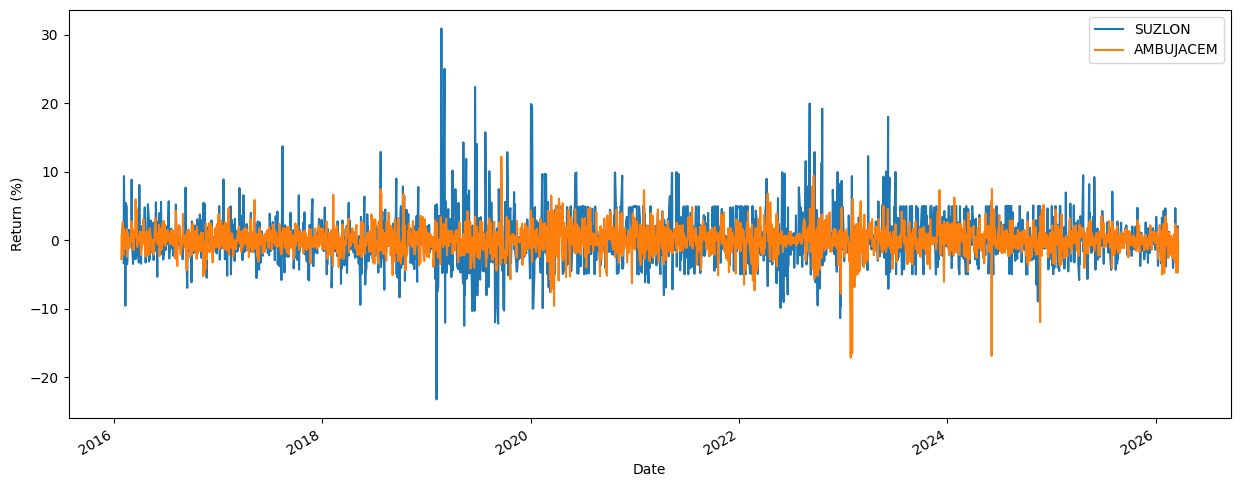

In [38]:
fig, ax = plt.subplots(figsize=(15, 6))
y_suzlon.plot(ax=ax, label="SUZLON")
y_ambuja.plot(ax=ax, label="AMBUJACEM")
ax.set_xlabel("Date")
ax.set_ylabel("Return (%)")
ax.legend()
plt.show()

> 📊 The two clouds share an axis, so the **wider band is the more
> volatile stock**. You should also see, in both, that big-swing stretches
> and quiet stretches arrive in *runs* — volatility clustering, the very
> feature GARCH exploits.

Create a histogram of `y_ambuja` with 25 bins. Label the x-axis
`"Daily Returns"`, the y-axis `"Frequency [count]"`, and title it
`"Distribution of Ambuja Cement Daily Returns"`. Expect a roughly
bell-shaped curve centred near zero.

**Code 8.3.4.2**:

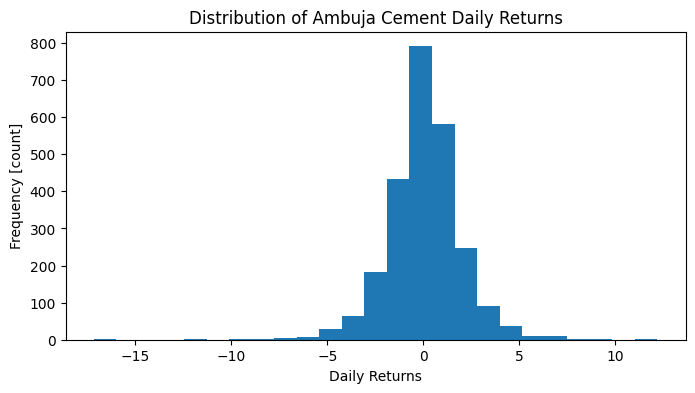

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_ambuja, bins=25)
ax.set_xlabel("Daily Returns")
ax.set_ylabel("Frequency [count]")
ax.set_title("Distribution of Ambuja Cement Daily Returns")
plt.show()

> 📊 The distribution is centred near zero and roughly symmetric — but look
> at the **tails**: a few days sit far from the centre, more than a true
> normal curve would allow. Those *fat tails* are why a constant-variance
> Gaussian under-states risk, and another nudge toward GARCH.

Calculate daily and annual volatility for both stocks, assigning
`suzlon_daily_vol`, `ambuja_daily_vol`, `suzlon_annual_vol`,
`ambuja_annual_vol`. Confirm Suzlon is the more volatile on both scales.

**Code Task 8.3.4.3**:

In [43]:
# Calculate daily volatility as the standard deviation of clean return series
suzlon_daily_vol = y_suzlon.std()
ambuja_daily_vol = y_ambuja.std()

# Annualize daily volatility using the square root of time rule (252 trading days)
suzlon_annual_vol = suzlon_daily_vol * np.sqrt(252)
ambuja_annual_vol = ambuja_daily_vol * np.sqrt(252)

print(
    "Suzlon  — daily:",
    round(suzlon_daily_vol, 4),
    " | annual:",
    round(suzlon_annual_vol, 4),
)
print(
    "Ambuja  — daily:",
    round(ambuja_daily_vol, 4),
    " | annual:",
    round(ambuja_annual_vol, 4),
)

Suzlon  — daily: 3.6129  | annual: 57.3529
Ambuja  — daily: 1.974  | annual: 31.3365


> 📊 The numbers put a figure on the picture: Suzlon's daily *and* annual
> volatility exceed Ambuja's, and each annual value is its daily one times
> $\sqrt{252}$. This ranking is what the Section-4 Checkpoint will assert.

Compute the 50-day rolling volatility of `y_ambuja` and plot it over the
daily returns. The rolling line should rise in turbulent periods and fall
in calm ones, making clustering visible.

**Code 8.3.4.4**:

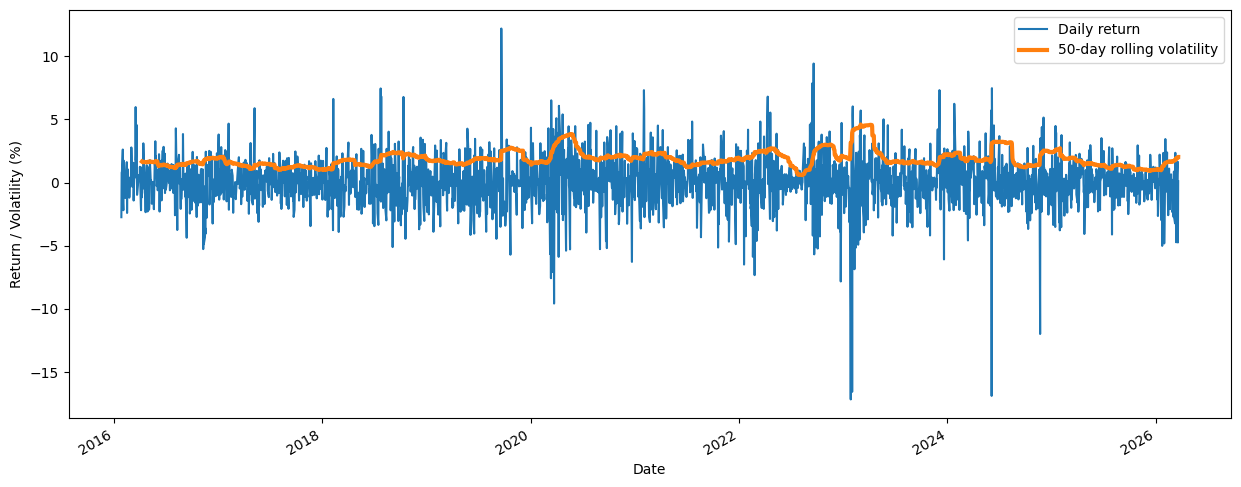

In [45]:
rolling_50d = y_ambuja.rolling(window=50).std().dropna()

fig, ax = plt.subplots(figsize=(15, 6))
y_ambuja.plot(ax=ax, label="Daily return")
rolling_50d.plot(
    ax=ax, label="50-day rolling volatility",
    linewidth=3
)
ax.set_xlabel("Date")
ax.set_ylabel("Return / Volatility (%)")
ax.legend()
plt.show()

> 📊 The thick rolling line is a **direct picture of time-varying
> volatility**: where it climbs, returns are swinging widely; where it
> dips, the market is calm. A constant-variance model would replace this
> whole wandering curve with one flat level — visibly wrong.

Plot the squared returns of `y_ambuja` as a time series. Squaring removes
the sign and emphasises magnitude; you should see clear clusters of large
values.

**Code 8.3.4.5**:

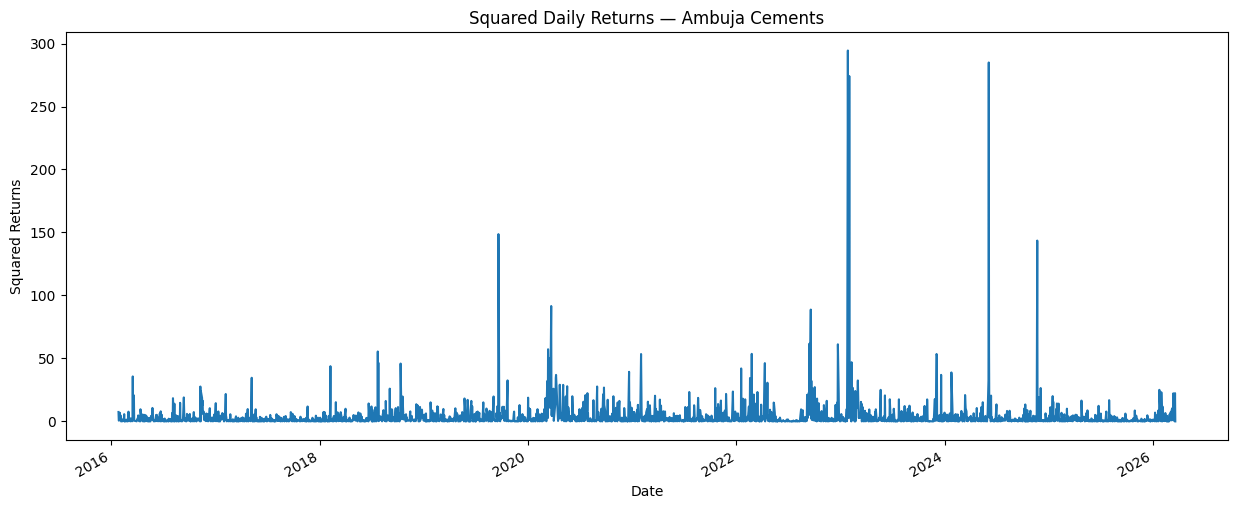

In [46]:
fig, ax = plt.subplots(figsize=(15, 6))
(y_ambuja ** 2).plot(ax=ax)
ax.set_xlabel("Date")
ax.set_ylabel("Squared Returns")
ax.set_title("Squared Daily Returns — Ambuja Cements")
plt.show()

> 📊 The tall spikes bunch together rather than scattering evenly — the
> signature of clustering, and the exact quantity (squared shocks) the ARCH
> term $\alpha\,\varepsilon_{t-1}^2$ feeds on.

Create ACF and PACF plots of the squared Ambuja returns. Significant lags
reveal how many past observations influence current volatility, guiding the
choice of $p$ and $q$.

**Code 8.3.4.6**:

In [48]:
# fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# plot_acf(y_ambuja ** 2, ax=axes[0])
# axes[0].set_xlabel("Lag [days]")
# axes[0].set_ylabel("Correlation Coefficient")
# axes[0].set_title("ACF of Squared Returns")

# plot_pacf(y_ambuja ** 2, ax=axes[1])
# axes[1].set_xlabel("Lag [days]")
# axes[1].set_ylabel("Correlation Coefficient")
# axes[1].set_title("PACF of Squared Returns")

# plt.tight_layout()
# plt.show()

> 📊 Unlike the synthetic series earlier, several **early lags now rise
> above the confidence band** — past squared returns genuinely predict
> future ones. That is the empirical green light for GARCH, and the slow
> decay across lags hints at the high persistence ($\alpha + \beta$ near 1)
> you'll see in the fit.

### Checkpoint

> 🧪 This Checkpoint pins down the comparison: Suzlon's daily and annual
> volatility must exceed Ambuja's, and the rolling series must have the
> expected length (`len(y_ambuja) - 49` for a 50-day window).

In [49]:
assert suzlon_daily_vol > ambuja_daily_vol, (
    "Expected Suzlon daily vol > Ambuja daily vol, "
    f"got {suzlon_daily_vol:.4f} vs {ambuja_daily_vol:.4f}"
)
assert suzlon_annual_vol > ambuja_annual_vol, (
    "Expected Suzlon annual vol > Ambuja annual vol, "
    f"got {suzlon_annual_vol:.4f} vs {ambuja_annual_vol:.4f}"
)
assert len(rolling_50d) == len(y_ambuja) - 49, (
    f"Rolling volatility length should be {len(y_ambuja) - 49}, "
    f"got {len(rolling_50d)}"
)

print("All checks passed.")

All checks passed.


> ✅ Passing confirms the exploratory findings are quantitatively solid —
> the data shows clustering and a clear volatility ranking, so a GARCH
> model is justified.

➡️ Intuition secured. Now fit the model and read what it learned.

## 5. Fit and Diagnose a GARCH Model

### Problem

With clustering confirmed, fit a GARCH model. You'll build a training set
(first 80% of observations), fit the model, read the summary for
coefficient significance and information criteria, and run a full set of
residual diagnostics (time-series plot, histogram, ACF of squared
standardised residuals).

### Approach

1.  Split `y_ambuja` into a training set (`y_train`) of the first 80%.
2.  Fit a `GARCH(1, 1)` on `y_train` with `rescale=False`.
3.  Inspect the summary — check coefficient significance and note AIC/BIC.
4.  Plot training returns with a $\pm 2\sigma$ conditional-volatility
    envelope.
5.  Plot the standardised residuals over time.
6.  Histogram of standardised residuals (25 bins).
7.  ACF of squared standardised residuals — all lags should be within the
    band.

> 💡 Tip: try different $p$ and $q$ (1, 2, 3) and compare AIC/BIC — lower
> is better, balancing fit against complexity. For most equity returns,
> GARCH(1, 1) is hard to beat, which is why it's the default here.

### Tasks

Create the training set `y_train` from the first 80% of `y_ambuja` and
print its length.

**Code Task 8.3.5.1**:

In [50]:
# Compute the integer split point at 80% of the series length
cutoff = int(len(y_ambuja) * 0.8)

# Chronologically slice the first 80% of data for training
y_train = y_ambuja.iloc[:cutoff]

print("y_train length:", len(y_train))
print(
    "y_train date range:",
    y_train.index[0].date(),
    "to",
    y_train.index[-1].date(),
)

y_train length: 2000
y_train date range: 2016-01-27 to 2024-03-06


Fit a GARCH(1, 1) on `y_train` with `rescale=False` and `disp="off"`. Print
the summary to inspect coefficients, p-values, AIC, and BIC.

**Code Task 8.3.5.2**:

In [52]:
model = arch_model(y_train, p=1, q=1, vol="GARCH").fit(disp="off")

print("model type:", type(model))
print(f"AIC: {model.aic:.2f}  |  BIC: {model.bic:.2f}")
model.summary()

model type: <class 'arch.univariate.base.ARCHModelResult'>
AIC: 8169.74  |  BIC: 8192.14


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4080.87
Distribution:                  Normal   AIC:                           8169.74
Method:            Maximum Likelihood   BIC:                           8192.14
                                        No. Observations:                 2000
Date:                Sat, Jun 27 2026   Df Residuals:                     1999
Time:                        19:49:54   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0997  3.905e-02      2.554  1.065e-02 [2.319e-02,  0.176]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.2367      0.130      1.822  6.844e-02 [-1.791e-02,  0.491]
alpha[1]       0.1027  3.586e-02      2.865  4.177e-03  [3.244e-02,  0.173]
beta[1]        0.8379  6.107e-02     13.721  7.592e-43    [  0.718,  0.958]
===========================================================================

Covariance estimator: robust
"""

> 🔍 Reading the summary against the theory
>
> - `omega`, `alpha[1]`, `beta[1]` are the $\omega$, $\alpha$, $\beta$ of
>   the GARCH(1,1) equation. Small p-values (≈ 0) mean each term is
>   statistically real.
> - Add `alpha[1] + beta[1]` to get the **persistence**. For equities it
>   typically lands near 0.9–0.99, confirming that volatility shocks fade
>   slowly — precisely the behaviour the rolling plot showed.
> - **AIC/BIC** are only meaningful *relative* to another fit; keep them to
>   compare against alternative $p, q$.

Plot the training returns with the $\pm 2$ standard-deviation conditional-
volatility envelope. The envelope should widen in turbulent periods and
narrow in calm ones.

**Code 8.3.5.3**:

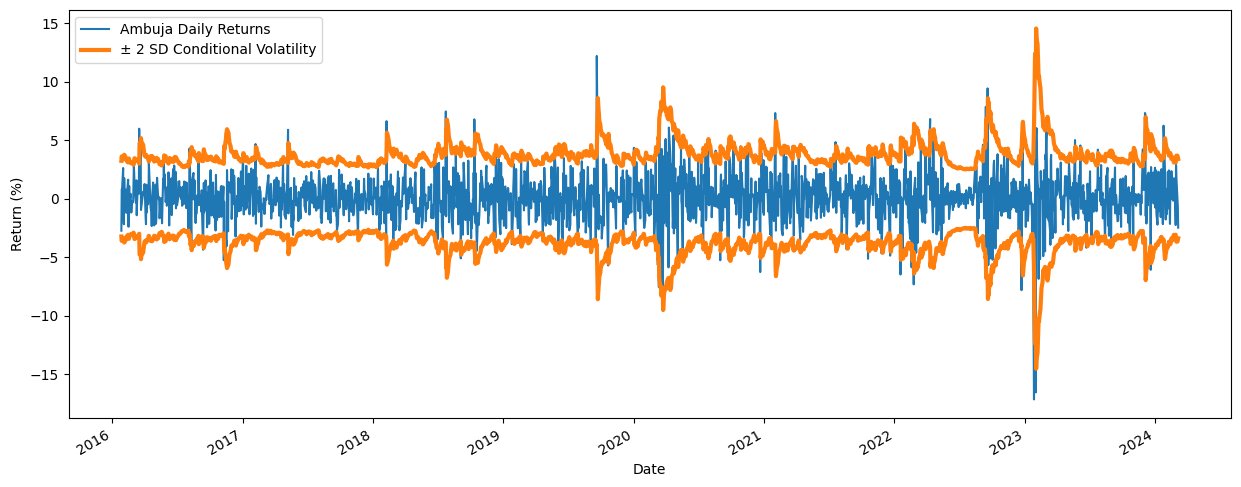

In [54]:
fig, ax = plt.subplots(figsize=(15, 6))

# Plot training returns
y_train.plot(ax=ax, label="Ambuja Daily Returns")

# Plot +2 SD conditional volatility
(2 * model.conditional_volatility).plot(
    ax=ax, color="C1",
    label="± 2 SD Conditional Volatility",
    linewidth=3
)

# Plot -2 SD conditional volatility (no extra legend entry)
(-2 * model.conditional_volatility.rename("")).plot(
    ax=ax, color="C1", linewidth=3
)

ax.set_xlabel("Date")
ax.set_ylabel("Return (%)")
ax.legend()
plt.show()

> 📊 The orange envelope is the model's *fitted* $\pm 2\sigma_t$. It should
> hug the returns — breathing wider exactly where the return spikes
> cluster, tighter where they calm. Roughly 95% of returns falling inside
> it is the visual sign the conditional variance is well-calibrated.

Plot the standardised residuals as a time series. If the model is adequate,
they should look like white noise with a roughly constant spread.

**Code 8.3.5.4**:

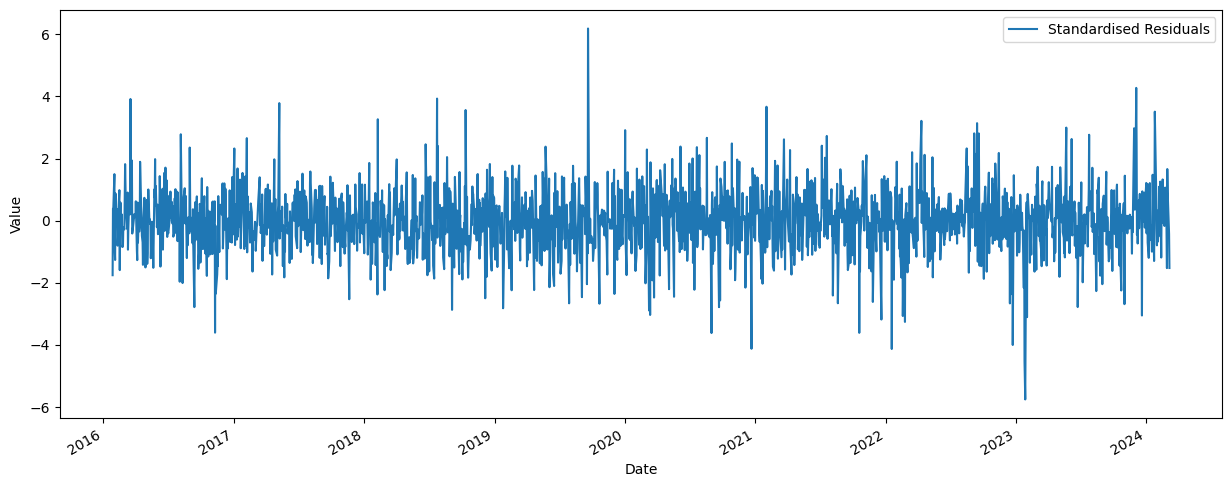

In [55]:
fig, ax = plt.subplots(figsize=(15, 6))
model.std_resid.plot(ax=ax, label="Standardised Residuals")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.legend()
plt.show()

> 📊 Recall $z_t = \varepsilon_t / \sigma_t$: dividing each shock by its
> *own* conditional volatility should **flatten** the clustering. A
> constant-width band here means the model has soaked up the time-varying
> variance — the calm and stormy stretches now look alike.

Create a 25-bin histogram of the standardised residuals. If the model
captures the dynamics, they should be approximately normal.

**Code 8.3.5.5**:

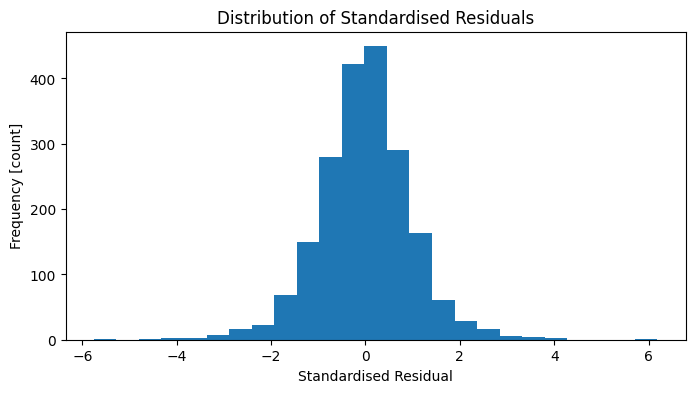

In [56]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(model.std_resid, bins=25)
ax.set_xlabel("Standardised Residual")
ax.set_ylabel("Frequency [count]")
ax.set_title("Distribution of Standardised Residuals")
plt.show()

> 📊 A roughly bell-shaped histogram supports the GARCH normality
> assumption. Slightly heavy tails are common and usually harmless; if they
> were severe you'd switch the error distribution (e.g. Student's *t* via
> `dist="t"` in `arch_model`).

Create an ACF plot of the **squared** standardised residuals. If GARCH has
captured the volatility structure, no lag should sit significantly outside
the band.

**Code 8.3.5.6**:

In [58]:
# fig, ax = plt.subplots(figsize=(10, 4))
# plot_acf(model.std_resid ** 2, ax=ax)
# ax.set_xlabel("Lag [days]")
# ax.set_ylabel("Correlation Coefficient")
# ax.set_title(
#     "ACF of Squared Standardised Residuals"
# )
# plt.tight_layout()
# plt.show()

> 📊 This is the decisive diagnostic. Compare it with the ACF of squared
> *raw* returns from Section 4, where early lags broke through the band.
> Here they should be **back inside** it — the leftover $z_t^2$ carry no
> structure, so the model extracted the clustering it was meant to.

### Checkpoint

> 🧪 The Checkpoint confirms the fit produced the objects later sections
> need: a `conditional_volatility` and `std_resid` attribute, with the
> conditional-volatility length matching `y_train`.

In [59]:
assert hasattr(model, "conditional_volatility"), (
    "model should have a conditional_volatility attribute — "
    "did you fit the GARCH model?"
)
assert hasattr(model, "std_resid"), (
    "model should have a std_resid attribute"
)
assert len(model.conditional_volatility) == len(y_train), (
    "conditional_volatility length should match y_train, "
    f"got {len(model.conditional_volatility)} vs {len(y_train)}"
)

print(f"Model AIC: {model.aic:.2f}")
print(f"Model BIC: {model.bic:.2f}")
print("All checks passed.")

Model AIC: 8169.74
Model BIC: 8192.14
All checks passed.


> ✅ Passing — with finite AIC/BIC printed — means you hold a fitted,
> diagnosed model. The remaining question is whether it generalises.

➡️ A good in-sample fit isn't enough. Test it forward in time.

## 6. Walk-Forward Validation

### Problem

You need to judge how well the GARCH model forecasts on **unseen** data.
Because the input is returns but the output is (latent) volatility, a
simple test-set RMSE against observed volatility is unavailable. Instead you
use **walk-forward validation**: repeatedly retrain on an expanding window,
forecast one step ahead, and overlay the predicted volatility on the actual
returns.

### Approach

1.  Set the test size to 20% of `y_ambuja`.
2.  Loop `test_size` times; each iteration: (a) slice `y_ambuja` up to the
    current boundary as the training window, (b) fit GARCH(1, 1), (c)
    extract the one-step-ahead volatility (square root of the forecast
    variance), (d) append it.
3.  Wrap the predictions in a `pd.Series` indexed by the test dates.
4.  Plot the test-period returns with $\pm 2 \times$ predicted volatility.

> ⚠️ Walk-forward validation **refits the model at every step**, so this
> cell takes a minute or two to run. That is expected, not a hang.

### Tasks

Run walk-forward validation over the test period. The idea is simple but has
several moving parts, so here it is step by step:

1.  **Decide the test size** — 20% of `y_ambuja`.
2.  **Loop through the test period.** On iteration `i`:
    -   Take all observations *before* the current test point as training
        data. The slice `y_ambuja.iloc[: -(test_size - i)]` grows by one
        row each iteration — the "expanding window."
    -   Fit a GARCH(1,1) on that window (as in Section 5).
    -   Forecast one step ahead: `model.forecast(horizon=1)` returns a
        variance; take the square root for volatility.
    -   Append the volatility value to a list.
3.  **After the loop**, wrap the list in a `pd.Series` indexed by the test
    dates.

Store the final Series in `y_test_wfv`.

**Code 8.3.6.1**:

In [60]:
predictions = []
test_size = int(len(y_ambuja) * 0.2)

for i in range(test_size):
    # Expanding training window
    y_wf_train = y_ambuja.iloc[: -(test_size - i)]

    # Fit GARCH(1,1)
    wf_model = arch_model(
        y_wf_train, p=1, q=1, rescale=False
    ).fit(disp="off")

    # One-step-ahead volatility (sqrt of variance)
    next_vol = (
        wf_model.forecast(horizon=1, reindex=False)
        .variance.iloc[0, 0] ** 0.5
    )
    predictions.append(next_vol)

# Build Series from predictions
y_test_wfv = pd.Series(
    predictions,
    index=y_ambuja.tail(test_size).index
)

print("y_test_wfv type:", type(y_test_wfv))
print("y_test_wfv shape:", y_test_wfv.shape)
y_test_wfv.head()

y_test_wfv type: <class 'pandas.Series'>
y_test_wfv shape: (500,)


2024-03-07    1.821879
2024-03-11    1.754939
2024-03-12    1.680560
2024-03-13    1.828137
2024-03-14    2.305618
dtype: float64

> 🧠 Why an *expanding* window (rather than a fixed-size sliding one)? Each
> forecast uses **every** observation available up to that day — mirroring
> how you'd deploy the model in production, retraining as new data arrives.
> It never peeks at the future, so the evaluation is honest.

Plot the test-period returns with the $\pm 2$ standard-deviation predicted-
volatility envelope. It should expand in volatile stretches and contract in
calm ones, confirming the model generalises.

**Code 8.3.6.2**:

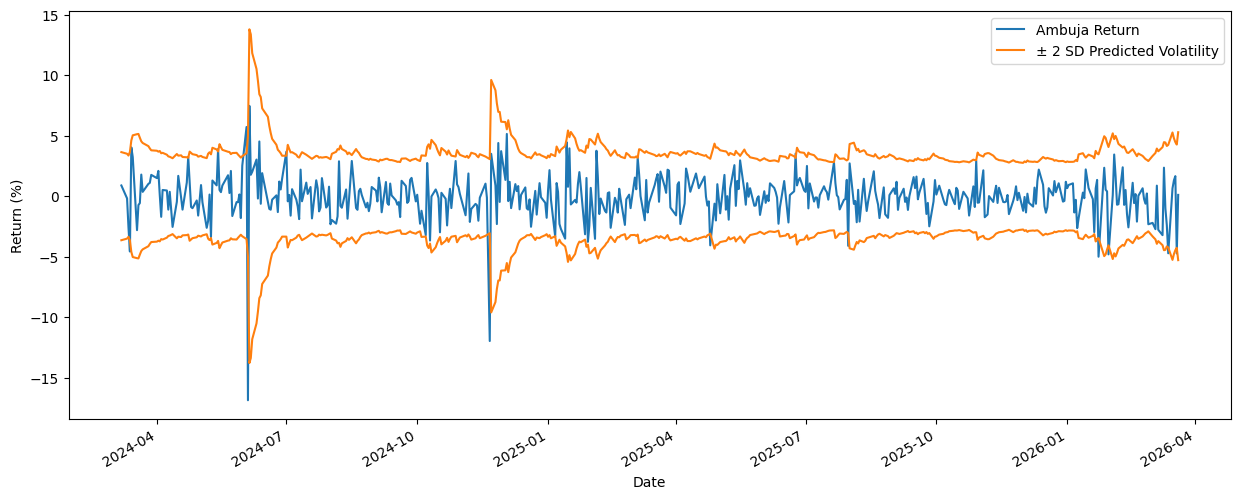

In [61]:
fig, ax = plt.subplots(figsize=(15, 6))

# Plot test-period returns
y_ambuja.tail(test_size).plot(
    ax=ax, label="Ambuja Return"
)

# Plot +2 SD predicted volatility
(2 * y_test_wfv).plot(
    ax=ax, color="C1",
    label="± 2 SD Predicted Volatility"
)

# Plot -2 SD predicted volatility
(-2 * y_test_wfv).plot(ax=ax, color="C1")

ax.set_xlabel("Date")
ax.set_ylabel("Return (%)")
ax.legend()
plt.show()

> 📊 This envelope is built entirely from **out-of-sample** forecasts, yet
> it should still track the test-period returns — widening before/around
> turbulent runs and tightening in quiet ones. That visual fit is the
> evidence the model works on data it never trained on.

### Checkpoint

> 🧪 The Checkpoint verifies the validation output: `y_test_wfv` is a
> `pd.Series` with one entry per test step, and every predicted volatility
> is **positive** (a variance forecast can never be negative, so its square
> root must be real and > 0).

In [62]:
assert isinstance(y_test_wfv, pd.Series), (
    f"y_test_wfv should be a pd.Series, got {type(y_test_wfv)}"
)
assert len(y_test_wfv) == test_size, (
    f"y_test_wfv should have {test_size} entries, "
    f"got {len(y_test_wfv)}"
)
assert (y_test_wfv > 0).all(), (
    "All predicted volatilities should be positive"
)

print("All checks passed.")

All checks passed.


> ✅ Passing means you have a vector of honest one-step-ahead volatility
> forecasts. The last task is to dress them for delivery over an API.

➡️ A model is only useful if something can consume it. Format the output.

## 7. Format Predictions for the API

### Problem

The project's goal is a deployable system. Your API will serve volatility
forecasts as JSON, so you need a function that takes the raw model forecast
(a DataFrame of variances with columns `h.1`, `h.2`, …) and returns a
dictionary mapping each business-day date (ISO 8601) to the predicted
**volatility** — the standard deviation, not the variance.

### Approach

1.  Generate a multi-step forecast with
    `model.forecast(horizon=n, reindex=False).variance`.
2.  Compute the forecast start date as the day after the last training
    observation, via `pd.DateOffset(days=1)`.
3.  Build a business-day range with `pd.bdate_range`.
4.  Convert each date to ISO 8601 with `.isoformat()`.
5.  Take the **square root** of the variance values to get volatility.
6.  Combine dates and values into a dictionary.
7.  Wrap it all in a `clean_prediction` function.

### Tasks

Generate a 5-day variance forecast from `model` and inspect its structure.
Note the columns `h.1`–`h.5` and that the index date is the last training
date.

**Code 8.3.7.1**:

In [63]:
prediction = model.forecast(
    horizon=5, reindex=False
).variance

print("prediction type:", type(prediction))
print("prediction shape:", prediction.shape)
prediction

prediction type: <class 'pandas.DataFrame'>
prediction shape: (1, 5)


,h.1,h.2,h.3,h.4,h.5
2024-03-06,3.319241,3.359025,3.396448,3.431652,3.464767


> 🔍 The forecast is a one-row DataFrame of **variances**, each column a
> step ahead. Two conversions stand between this and an API response: the
> values need a square root (variance → volatility), and the column labels
> need to become real calendar dates.

Build the ISO 8601 date index for the forecast. Start from the day after the
last training date and generate business days only (weekends skipped).

**Code 8.3.7.2**:

In [64]:
# Forecast start: day after last training observation
start = prediction.index[0] + pd.DateOffset(days=1)

# Generate business-day dates
pred_dates = pd.bdate_range(
    start=start, periods=prediction.shape[1]
)

# Convert to ISO 8601 strings
pred_index = [d.isoformat() for d in pred_dates]

print("pred_index type:", type(pred_index))
print("pred_index length:", len(pred_index))
pred_index

pred_index type: <class 'list'>
pred_index length: 5


['2024-03-07T00:00:00',
 '2024-03-08T00:00:00',
 '2024-03-11T00:00:00',
 '2024-03-12T00:00:00',
 '2024-03-13T00:00:00']

> 📌 Using `pd.bdate_range` (not a plain calendar range) ensures forecast
> dates land only on trading days — a forecast labelled "Saturday" would be
> meaningless to a markets client.

Now write `clean_prediction`, which takes a variance-forecast DataFrame and
returns a dictionary mapping ISO 8601 date strings to predicted volatility.
Test it with a 10-day forecast.

**Code Task 8.3.7.3**:

In [65]:
def clean_prediction(prediction):
    """Convert a variance forecast DataFrame to a dict.

    Parameters
    ----------
    prediction : pd.DataFrame
        Variance forecast from
        ``ARCHModelForecast.variance``.

    Returns
    -------
    dict
        Keys are ISO 8601 date strings (business days).
        Values are predicted volatility (std dev).
    """
    # 1. Compute start date (extract dates from the forecast index)
    start = prediction.index[0]
    pred_dates = pd.bdate_range(start=start, periods=prediction.shape[1])
    pred_index = pred_dates.strftime("%Y-%m-%d")

    # 2. Square root of variance = volatility
    data = prediction.values.flatten() ** 0.5

    pred_series = pd.Series(data, index=pred_index)
    return pred_series.to_dict()


# Test with a 10-day forecast
prediction_10 = model.forecast(horizon=10, reindex=False).variance
prediction_formatted = clean_prediction(prediction_10)

print("Type:", type(prediction_formatted))
print("Number of entries:", len(prediction_formatted))
prediction_formatted

Type: <class 'dict'>
Number of entries: 10


{'2024-03-06': 1.8218785153577408,
 '2024-03-07': 1.832764268213249,
 '2024-03-08': 1.8429455851645158,
 '2024-03-11': 1.8524718675350842,
 '2024-03-12': 1.8613885470022509,
 '2024-03-13': 1.8697374725857354,
 '2024-03-14': 1.8775572507353655,
 '2024-03-15': 1.884883545444996,
 '2024-03-18': 1.8917493441198538,
 '2024-03-19': 1.898185193960485}

> ➡️ This single function is the **bridge to deployment**: it turns raw
> model output into clean, JSON-serialisable data. In Lesson 4 it becomes a
> method on the `GarchModel` class, called directly inside the API's
> `/predict` endpoint.

### Checkpoint

> 🧪 The final Checkpoint validates the API contract: `clean_prediction`
> returns a `dict` of the right length, with **string** keys (ISO dates) and
> **positive float** values (volatilities). This is exactly the shape the
> Lesson 4 endpoint will emit.

In [67]:
assert isinstance(prediction_formatted, dict), (
    "prediction_formatted should be a dict, "
    f"got {type(prediction_formatted)}"
)
assert len(prediction_formatted) == 10, (
    "prediction_formatted should have 10 entries, "
    f"got {len(prediction_formatted)}"
)
assert all(isinstance(k, str) for k in prediction_formatted), (
    "All keys should be strings (ISO 8601 dates)"
)
assert all(
    isinstance(v, float) for v in prediction_formatted.values()
), (
    "All values should be floats (volatility)"
)
assert all(v > 0 for v in prediction_formatted.values()), (
    "All volatility values should be positive"
)

print("All checks passed.")
print("Sample:", dict(list(prediction_formatted.items())[:3]))

All checks passed.
Sample: {'2024-03-06': 1.8218785153577408, '2024-03-07': 1.832764268213249, '2024-03-08': 1.8429455851645158}


> ✅ Passing — with a sample of date→volatility pairs printed — means your
> forecasts are deployment-ready.

# Wrap-up

In this notebook you:

-   Computed daily and annual volatility for two stocks and confirmed
    Suzlon Energy is more volatile than Ambuja Cements.
-   Visualised volatility clustering with rolling standard deviation and
    squared-return plots.
-   Used ACF and PACF of squared returns to justify a GARCH model.
-   Fit a GARCH(1, 1) with the `arch` library and interpreted its summary
    (coefficients, AIC, BIC).
-   Diagnosed the model with standardised-residual plots (time series,
    histogram, ACF of squared residuals).
-   Performed walk-forward validation to evaluate out-of-sample forecasts.
-   Built a `clean_prediction` function that reformats the variance
    forecast into a dictionary keyed by ISO 8601 business-day dates —
    ready to serve as JSON.

> 🧠 The idea to carry forward: GARCH turns "volatility clusters" into a
> precise recursion — tomorrow's variance is a baseline plus a reaction to
> yesterday's shock ($\alpha$) plus a carry-over of yesterday's variance
> ($\beta$). The persistence $\alpha + \beta$, close to 1 for equities, is
> *why* risk arrives in runs.

➡️ **Next**, you will package the data-loading, model-fitting, and
prediction logic into a clean, modular pipeline — a `GarchModel` class and a
FastAPI service — that can be **deployed** as a reusable prediction system.